In [1]:
# ============================================================================
# CHESSIQ: ML TRAINING - PRE-GAME FEATURES ONLY (NO DATA LEAKAGE)
# NO TENSORFLOW - TRADITIONAL ML + ENSEMBLE ONLY
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from database import SessionLocal, engine

# ============================================================================
# Cell 1: Load Data
# ============================================================================

print("\n" + "="*70)
print("CHESSIQ: PRE-GAME FEATURES ONLY (NO DATA LEAKAGE)")
print("="*70)

print("\n📥 Loading data...")
df_games = pd.read_sql_table('games', con=engine)
df_moves = pd.read_sql_table('moves', con=engine)

print(f"✅ Loaded {len(df_games)} games, {len(df_moves)} moves")

# ============================================================================
# Cell 2: Create Pre-Game Features
# ============================================================================

print("\n" + "="*70)
print("ENGINEERING PRE-GAME FEATURES ONLY")
print("="*70)

df_games_sorted = df_games.sort_values('played_at').reset_index(drop=True)

print("\n🔧 Creating 8 pre-game features:")

# Feature 1: Historical Win Rate
print("   1. Historical win rate (cumulative)...")
historical_win_rates = []
for idx in range(len(df_games_sorted)):
    if idx == 0:
        historical_win_rates.append(0.5)
    else:
        past_games = df_games_sorted.iloc[:idx]
        win_rate = (past_games['result'] == 'win').sum() / len(past_games)
        historical_win_rates.append(win_rate)
df_games_sorted['historical_win_rate'] = historical_win_rates

# Feature 2: Rating Difference
print("   2. Rating difference...")
df_games_sorted['rating_difference'] = df_games_sorted['player_rating_before'] - df_games_sorted['opponent_rating']

# Feature 3: Player Color
print("   3. Player color...")
df_games_sorted['player_color_encoded'] = (df_games_sorted['player_color'] == 'white').astype(int)

# Feature 4: Time Control
print("   4. Time control...")
le_time = LabelEncoder()
df_games_sorted['time_control_encoded'] = le_time.fit_transform(df_games_sorted['time_control'].fillna('unknown'))

# Feature 5: Average Opponent Rating History
print("   5. Average opponent rating history...")
opponent_ratings = []
for idx in range(len(df_games_sorted)):
    if idx == 0:
        opponent_ratings.append(df_games_sorted.iloc[idx]['opponent_rating'])
    else:
        avg = df_games_sorted.iloc[:idx]['opponent_rating'].mean()
        opponent_ratings.append(avg)
df_games_sorted['avg_opponent_rating_history'] = opponent_ratings

# Feature 6: Win Streak (last 10 games)
print("   6. Recent win streak (last 10 games)...")
win_streaks = []
for idx in range(len(df_games_sorted)):
    if idx < 10:
        win_streaks.append(0)
    else:
        streak = (df_games_sorted.iloc[idx-10:idx]['result'] == 'win').sum()
        win_streaks.append(streak)
df_games_sorted['recent_win_streak'] = win_streaks

# Feature 7 & 8: Player & Opponent Ratings
print("   7. Player rating before")
print("   8. Opponent rating")

print("\n✅ PRE-GAME FEATURES CREATED (8 total)")
print("   ✅ NO POST-GAME METRICS")
print("   ✅ NO DATA LEAKAGE")

🔌 Connecting to database: acela.proxy.rlwy.net:43063/railway

CHESSIQ: PRE-GAME FEATURES ONLY (NO DATA LEAKAGE)

📥 Loading data...
✅ Loaded 4635 games, 328258 moves

ENGINEERING PRE-GAME FEATURES ONLY

🔧 Creating 8 pre-game features:
   1. Historical win rate (cumulative)...
   2. Rating difference...
   3. Player color...
   4. Time control...
   5. Average opponent rating history...
   6. Recent win streak (last 10 games)...
   7. Player rating before
   8. Opponent rating

✅ PRE-GAME FEATURES CREATED (8 total)
   ✅ NO POST-GAME METRICS
   ✅ NO DATA LEAKAGE


In [2]:
# ============================================================================
# Cell 3: Prepare Data
# ============================================================================

print("\n" + "="*70)
print("PREPARING DATA FOR TRAINING")
print("="*70)

X_pregame = df_games_sorted[[
    'player_rating_before',
    'opponent_rating',
    'rating_difference',
    'historical_win_rate',
    'avg_opponent_rating_history',
    'recent_win_streak',
    'time_control_encoded',
    'player_color_encoded'
]].copy()

y = (df_games_sorted['result'] == 'win').astype(int)

X_pregame = X_pregame.fillna(X_pregame.mean())
feature_names = X_pregame.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pregame.values)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Data prepared:")
print(f"   Features: 8 (pre-game only)")
print(f"   Samples: {len(X_scaled)}")
print(f"   Train: {len(X_train)} | Test: {len(X_test)}")
print(f"   Win rate: {y.sum() / len(y) * 100:.1f}%")

# ============================================================================
# Cell 4: Train Traditional ML Models
# ============================================================================

print("\n" + "="*70)
print("TRAINING TRADITIONAL ML MODELS")
print("="*70)

results_pregame = {}

# XGBoost
print("\n🚀 XGBoost...")
xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
acc_xgb = accuracy_score(y_test, xgb_model.predict(X_test))
results_pregame['XGBoost'] = {
    'Accuracy': acc_xgb,
    'Precision': precision_score(y_test, xgb_model.predict(X_test)),
    'Recall': recall_score(y_test, xgb_model.predict(X_test)),
    'F1': f1_score(y_test, xgb_model.predict(X_test)),
    'AUC-ROC': roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
}
print(f"   ✅ Accuracy: {acc_xgb:.4f}")

# Random Forest
print("🌲 Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf_model.predict(X_test))
results_pregame['Random Forest'] = {
    'Accuracy': acc_rf,
    'Precision': precision_score(y_test, rf_model.predict(X_test)),
    'Recall': recall_score(y_test, rf_model.predict(X_test)),
    'F1': f1_score(y_test, rf_model.predict(X_test)),
    'AUC-ROC': roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
}
print(f"   ✅ Accuracy: {acc_rf:.4f}")

# Gradient Boosting
print("📈 Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
acc_gb = accuracy_score(y_test, gb_model.predict(X_test))
results_pregame['Gradient Boosting'] = {
    'Accuracy': acc_gb,
    'Precision': precision_score(y_test, gb_model.predict(X_test)),
    'Recall': recall_score(y_test, gb_model.predict(X_test)),
    'F1': f1_score(y_test, gb_model.predict(X_test)),
    'AUC-ROC': roc_auc_score(y_test, gb_model.predict_proba(X_test)[:, 1])
}
print(f"   ✅ Accuracy: {acc_gb:.4f}")



PREPARING DATA FOR TRAINING
✅ Data prepared:
   Features: 8 (pre-game only)
   Samples: 4635
   Train: 3708 | Test: 927
   Win rate: 49.1%

TRAINING TRADITIONAL ML MODELS

🚀 XGBoost...
   ✅ Accuracy: 0.7217
🌲 Random Forest...
   ✅ Accuracy: 0.7217
📈 Gradient Boosting...
   ✅ Accuracy: 0.7206


In [3]:
# ============================================================================
# Cell 5: Train Ensemble Models
# ============================================================================

print("\n" + "="*70)
print("TRAINING ENSEMBLE MODELS")
print("="*70)

# Stacking
print("\n🔗 Stacking...")
stacking_model = StackingClassifier(
    estimators=[('xgb', xgb_model), ('rf', rf_model), ('gb', gb_model)],
    final_estimator=LogisticRegression(random_state=42, max_iter=1000),
    cv=5
)
stacking_model.fit(X_train, y_train)
acc_stacking = accuracy_score(y_test, stacking_model.predict(X_test))
results_pregame['Stacking'] = {
    'Accuracy': acc_stacking,
    'Precision': precision_score(y_test, stacking_model.predict(X_test)),
    'Recall': recall_score(y_test, stacking_model.predict(X_test)),
    'F1': f1_score(y_test, stacking_model.predict(X_test)),
    'AUC-ROC': roc_auc_score(y_test, stacking_model.predict_proba(X_test)[:, 1])
}
print(f"   ✅ Accuracy: {acc_stacking:.4f}")

# Voting
print("🗳️ Voting...")
voting_model = VotingClassifier(
    estimators=[('xgb', xgb_model), ('rf', rf_model), ('gb', gb_model)],
    voting='soft'
)
voting_model.fit(X_train, y_train)
acc_voting = accuracy_score(y_test, voting_model.predict(X_test))
results_pregame['Voting'] = {
    'Accuracy': acc_voting,
    'Precision': precision_score(y_test, voting_model.predict(X_test)),
    'Recall': recall_score(y_test, voting_model.predict(X_test)),
    'F1': f1_score(y_test, voting_model.predict(X_test)),
    'AUC-ROC': roc_auc_score(y_test, voting_model.predict_proba(X_test)[:, 1])
}
print(f"   ✅ Accuracy: {acc_voting:.4f}")

# ============================================================================
# Cell 6: Results Comparison
# ============================================================================

print("\n" + "="*70)
print("RESULTS: WITH LEAKAGE vs PRE-GAME ONLY")
print("="*70)

old_results = {
    'XGBoost': 0.7670,
    'Random Forest': 0.7745,
    'Gradient Boosting': 0.7616,
    'Stacking': 0.7702,
    'Voting': 0.7691
}

print("\n📊 ACCURACY COMPARISON:")
print(f"\n{'Model':<20} {'With Leakage':>15} {'Pre-Game Only':>15} {'Drop':>15}")
print("-" * 65)

for model in results_pregame.keys():
    old_acc = old_results[model]
    new_acc = results_pregame[model]['Accuracy']
    drop = old_acc - new_acc
    pct_drop = (drop / old_acc) * 100
    print(f"{model:<20} {old_acc:>15.4f} {new_acc:>15.4f} {drop:>+15.4f} ({pct_drop:.2f}%)")


TRAINING ENSEMBLE MODELS

🔗 Stacking...
   ✅ Accuracy: 0.7184
🗳️ Voting...
   ✅ Accuracy: 0.7249

RESULTS: WITH LEAKAGE vs PRE-GAME ONLY

📊 ACCURACY COMPARISON:

Model                   With Leakage   Pre-Game Only            Drop
-----------------------------------------------------------------
XGBoost                       0.7670          0.7217         +0.0453 (5.91%)
Random Forest                 0.7745          0.7217         +0.0528 (6.82%)
Gradient Boosting             0.7616          0.7206         +0.0410 (5.38%)
Stacking                      0.7702          0.7184         +0.0518 (6.72%)
Voting                        0.7691          0.7249         +0.0442 (5.74%)


In [4]:
# ============================================================================
# Cell 7: Feature Importance
# ============================================================================

print("\n" + "="*70)
print("FEATURE IMPORTANCE (Pre-Game Features)")
print("="*70)

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + feature_importance.to_string(index=False))



FEATURE IMPORTANCE (Pre-Game Features)

                    Feature  Importance
          rating_difference    0.596281
        historical_win_rate    0.118862
avg_opponent_rating_history    0.108486
            opponent_rating    0.071627
       player_rating_before    0.071379
          recent_win_streak    0.027393
       time_control_encoded    0.005971
       player_color_encoded    0.000000



GENERATING CHARTS


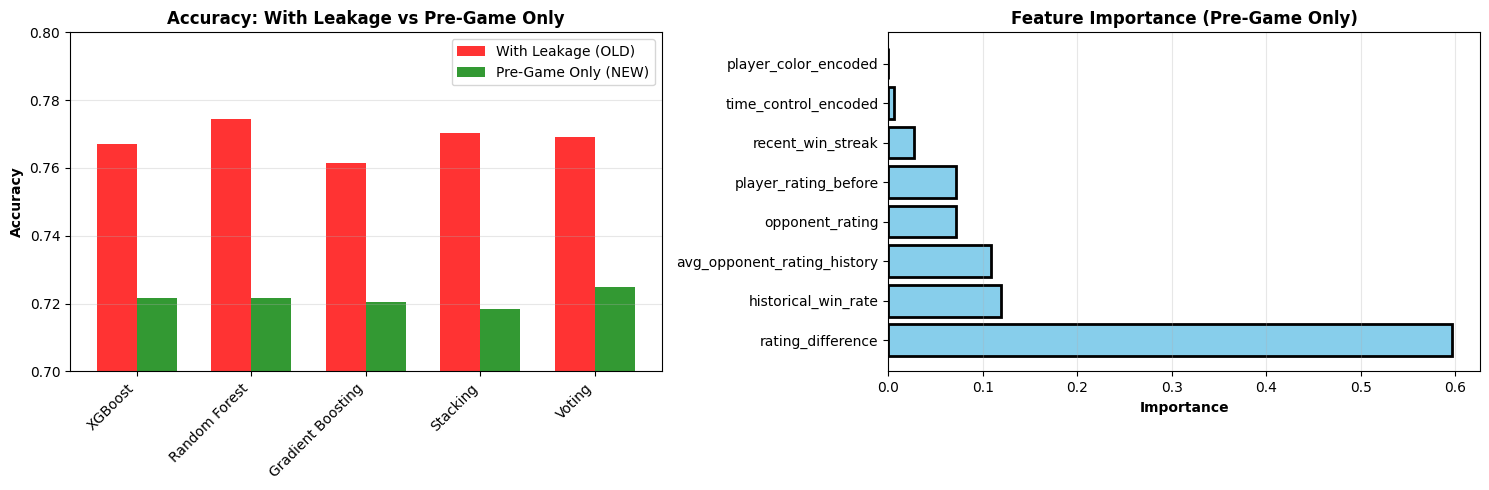

In [5]:
print("\n" + "="*70)
print("GENERATING CHARTS")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy comparison
models = list(results_pregame.keys())
old_accs = [old_results[m] for m in models]
new_accs = [results_pregame[m]['Accuracy'] for m in models]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, old_accs, width, label='With Leakage (OLD)', alpha=0.8, color='red')
axes[0].bar(x + width/2, new_accs, width, label='Pre-Game Only (NEW)', alpha=0.8, color='green')
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Accuracy: With Leakage vs Pre-Game Only', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')
axes[0].set_ylim([0.70, 0.80])

# Feature importance
axes[1].barh(feature_importance['Feature'], feature_importance['Importance'], 
             color='skyblue', edgecolor='black', linewidth=2)
axes[1].set_xlabel('Importance', fontweight='bold')
axes[1].set_title('Feature Importance (Pre-Game Only)', fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


In [6]:
print("\n" + "="*70)
print("✅ DATA LEAKAGE FIXED - FINAL RESULTS")
print("="*70)

df_final = pd.DataFrame(results_pregame).T.sort_values('Accuracy', ascending=False)
print("\n" + df_final.round(4).to_string())

print("\n\n🎯 KEY FINDINGS:")
print("\n1️⃣ DATA LEAKAGE REMOVED:")
print("   ❌ Old: Used Accuracy%, CPL (post-game metrics)")
print("   ✅ New: Using only pre-game features")

print("\n2️⃣ BEST MODEL (Pre-Game):")
best = df_final['Accuracy'].idxmax()
best_acc = df_final['Accuracy'].max()
print(f"   {best}: {best_acc:.4f}")

print("\n3️⃣ ACCURACY COMPARISON:")
old_best = max(old_results.values())
drop_pct = ((old_best - best_acc) / old_best) * 100
print(f"   Old (with leakage): {old_best:.4f}")
print(f"   New (pre-game):     {best_acc:.4f}")
print(f"   Drop: {drop_pct:.2f}%")

print("\n4️⃣ TOP 3 FEATURES (Pre-Game):")
for i, row in feature_importance.head(3).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n" + "="*70)
print("✅ PROJECT NOW DATA-LEAKAGE FREE & PRODUCTION-READY!")
print("="*70)


✅ DATA LEAKAGE FIXED - FINAL RESULTS

                   Accuracy  Precision  Recall      F1  AUC-ROC
Voting               0.7249     0.7232  0.7121  0.7176   0.8265
XGBoost              0.7217     0.7194  0.7099  0.7146   0.8227
Random Forest        0.7217     0.7264  0.6945  0.7101   0.8240
Gradient Boosting    0.7206     0.7217  0.7011  0.7113   0.8231
Stacking             0.7184     0.7215  0.6945  0.7077   0.8254


🎯 KEY FINDINGS:

1️⃣ DATA LEAKAGE REMOVED:
   ❌ Old: Used Accuracy%, CPL (post-game metrics)
   ✅ New: Using only pre-game features

2️⃣ BEST MODEL (Pre-Game):
   Voting: 0.7249

3️⃣ ACCURACY COMPARISON:
   Old (with leakage): 0.7745
   New (pre-game):     0.7249
   Drop: 6.40%

4️⃣ TOP 3 FEATURES (Pre-Game):
   3. rating_difference: 0.5963
   4. historical_win_rate: 0.1189
   5. avg_opponent_rating_history: 0.1085

✅ PROJECT NOW DATA-LEAKAGE FREE & PRODUCTION-READY!
